# Model Comparison

In [58]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [59]:
results_folder = Path("../results")
predictions_folder = results_folder / "predictions"
figures_folder = results_folder / "figures"
comparison_figures_folder = figures_folder / "model_comparison"

comparison_figures_folder.mkdir(
    parents=True,
    exist_ok=True
)

print("Results folder:")
print(results_folder.resolve())

print("\nComparison figures folder:")
print(comparison_figures_folder.resolve())

Results folder:
/Volumes/GraceHardDrive/aml_final_project/results

Comparison figures folder:
/Volumes/GraceHardDrive/aml_final_project/results/figures/model_comparison


In [60]:
classification_metrics = pd.read_csv(
    results_folder / "classification_metrics.csv"
)

linear_regression_metrics = pd.read_csv(
    results_folder / "linear_regression_metrics.csv"
)

training_testing_accuracy = pd.read_csv(
    results_folder / "training_testing_accuracy.csv"
)

predictions = pd.read_csv(
    predictions_folder / "model_predictions.csv"
)

logistic_coefficients = pd.read_csv(
    results_folder / "logistic_regression_coefficients.csv"
)

knn_grid_results = pd.read_csv(
    results_folder / "knn_grid_search_results.csv"
)

In [61]:
classification_metrics

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Linear Regression,0.8502,0.6667,0.0310,0.0593,0.6952
1,Logistic Regression,0.8491,0.5294,0.0698,0.1233,0.6996
2,KNN,0.8479,0.5000,0.0233,0.0444,0.6511


In [62]:
training_testing_accuracy

,Model,Training Accuracy,Testing Accuracy
0,Linear Regression,0.853097,0.850236
1,Logistic Regression,0.857227,0.849057
2,KNN,1.000000,0.847877


In [63]:
predictions.head()

,Actual,Linear_Predicted_Value,Linear_Predicted_Class,Logistic_Probability,Logistic_Predicted_Class,KNN_Probability,KNN_Predicted_Class
0,0,0.205354,0,0.195314,0,0.176500,0
1,0,0.231530,0,0.215267,0,0.196381,0
2,1,0.222698,0,0.201414,0,0.282583,0
3,0,0.444408,0,0.524433,1,0.304556,0
4,0,0.220795,0,0.209047,0,0.098704,0


In [64]:
logistic_coefficients.head()

,Feature,Coefficient,Odds Ratio
0,prevalentStroke,0.834893,2.304567
1,age,0.572034,1.771867
2,male,0.452382,1.572052
3,BPMeds,0.334118,1.396708
4,sysBP,0.323828,1.382409


In [65]:
knn_grid_results.head()

,param_n_neighbors,param_weights,param_metric,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,31,distance,euclidean,1.000000,0.691919,0.021103,1
1,31,uniform,euclidean,0.773168,0.691314,0.020868,2
2,25,distance,manhattan,1.000000,0.688361,0.019706,3
3,29,distance,euclidean,1.000000,0.687416,0.021296,4
4,27,distance,manhattan,1.000000,0.686875,0.019294,5


In [66]:
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
]

classification_metrics[metric_columns] = (
    classification_metrics[metric_columns]
    .round(4)
)

classification_metrics

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Linear Regression,0.8502,0.6667,0.0310,0.0593,0.6952
1,Logistic Regression,0.8491,0.5294,0.0698,0.1233,0.6996
2,KNN,0.8479,0.5000,0.0233,0.0444,0.6511


In [67]:
metrics_sorted_by_auc = (
    classification_metrics
    .sort_values(
        by="ROC AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

metrics_sorted_by_auc

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.8491,0.5294,0.0698,0.1233,0.6996
1,Linear Regression,0.8502,0.6667,0.0310,0.0593,0.6952
2,KNN,0.8479,0.5000,0.0233,0.0444,0.6511


In [68]:
best_models = []

for metric in metric_columns:
    best_index = classification_metrics[
        metric
    ].idxmax()

    best_models.append({
        "Metric": metric,
        "Best Model": classification_metrics.loc[
            best_index,
            "Model"
        ],
        "Best Score": classification_metrics.loc[
            best_index,
            metric
        ]
    })

best_models_df = pd.DataFrame(best_models)

best_models_df

,Metric,Best Model,Best Score
0,Accuracy,Linear Regression,0.8502
1,Precision,Linear Regression,0.6667
2,Recall,Logistic Regression,0.0698
3,F1 Score,Logistic Regression,0.1233
4,ROC AUC,Logistic Regression,0.6996


In [69]:
metrics_long = classification_metrics.melt(
    id_vars="Model",
    value_vars=metric_columns,
    var_name="Metric",
    value_name="Score"
)

metrics_long.head()

,Model,Metric,Score
0,Linear Regression,Accuracy,0.8502
1,Logistic Regression,Accuracy,0.8491
2,KNN,Accuracy,0.8479
3,Linear Regression,Precision,0.6667
4,Logistic Regression,Precision,0.5294


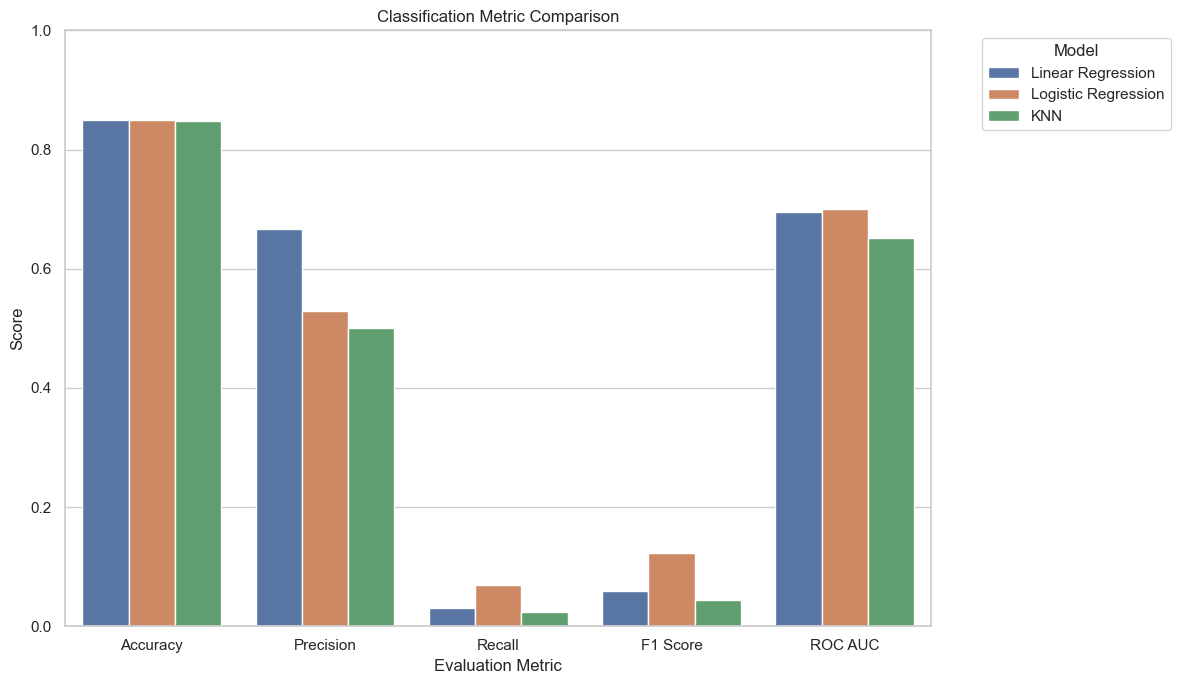

In [70]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=metrics_long,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Classification Metric Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(
    title="Model",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "all_metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

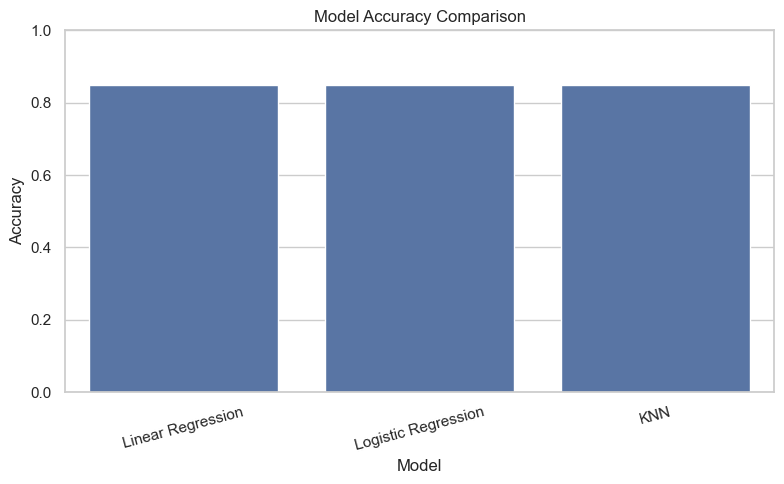

In [71]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=classification_metrics,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

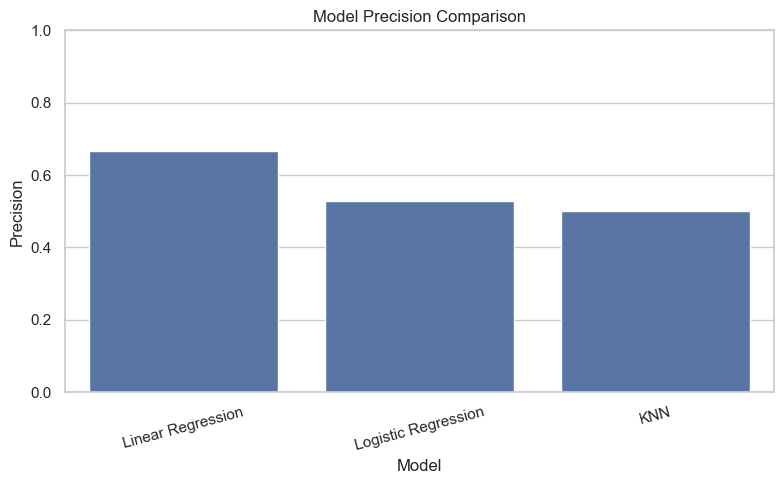

In [72]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=classification_metrics,
    x="Model",
    y="Precision"
)

plt.title("Model Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "precision_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

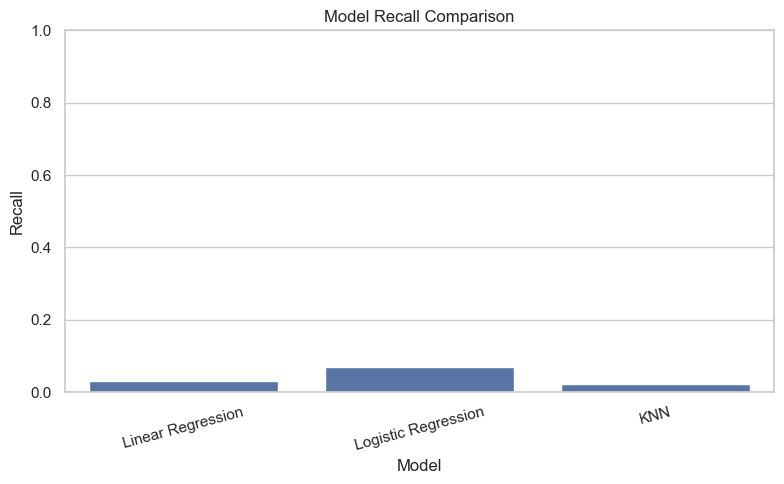

In [73]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=classification_metrics,
    x="Model",
    y="Recall"
)

plt.title("Model Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "recall_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

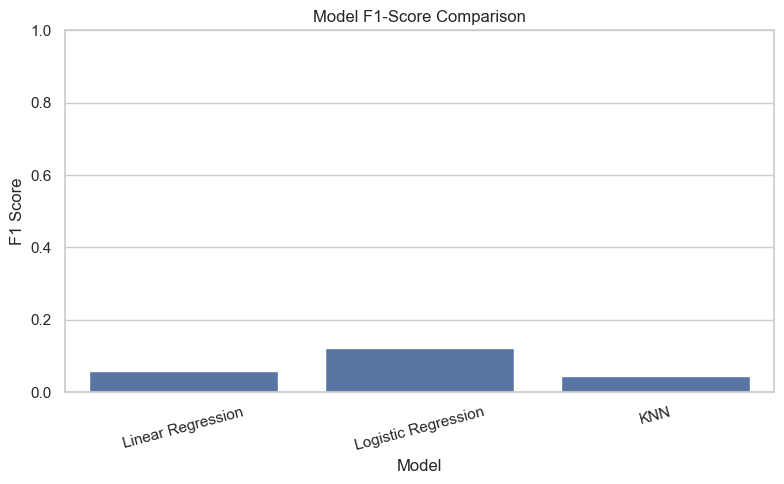

In [74]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=classification_metrics,
    x="Model",
    y="F1 Score"
)

plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "f1_score_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

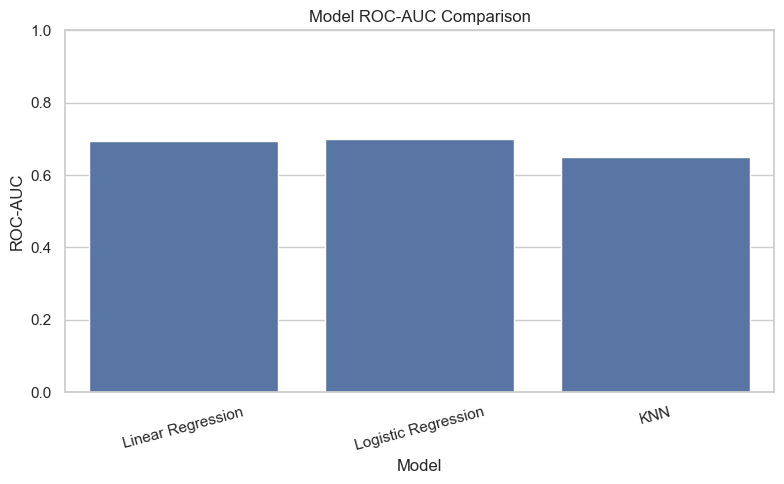

In [75]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=classification_metrics,
    x="Model",
    y="ROC AUC"
)

plt.title("Model ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
training_testing_accuracy[
    [
        "Training Accuracy",
        "Testing Accuracy"
    ]
] = training_testing_accuracy[
    [
        "Training Accuracy",
        "Testing Accuracy"
    ]
].round(4)

training_testing_accuracy

,Model,Training Accuracy,Testing Accuracy
0,Linear Regression,0.8531,0.8502
1,Logistic Regression,0.8572,0.8491
2,KNN,1.0000,0.8479


In [77]:
training_testing_accuracy[
    "Accuracy Gap"
] = (
    training_testing_accuracy[
        "Training Accuracy"
    ]
    -
    training_testing_accuracy[
        "Testing Accuracy"
    ]
)

training_testing_accuracy[
    "Accuracy Gap"
] = training_testing_accuracy[
    "Accuracy Gap"
].round(4)

training_testing_accuracy

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Linear Regression,0.8531,0.8502,0.0029
1,Logistic Regression,0.8572,0.8491,0.0081
2,KNN,1.0000,0.8479,0.1521


In [78]:
accuracy_long = training_testing_accuracy.melt(
    id_vars="Model",
    value_vars=[
        "Training Accuracy",
        "Testing Accuracy"
    ],
    var_name="Dataset",
    value_name="Accuracy"
)

accuracy_long

,Model,Dataset,Accuracy
0,Linear Regression,Training Accuracy,0.8531
1,Logistic Regression,Training Accuracy,0.8572
2,KNN,Training Accuracy,1.0000
3,Linear Regression,Testing Accuracy,0.8502
4,Logistic Regression,Testing Accuracy,0.8491
5,KNN,Testing Accuracy,0.8479


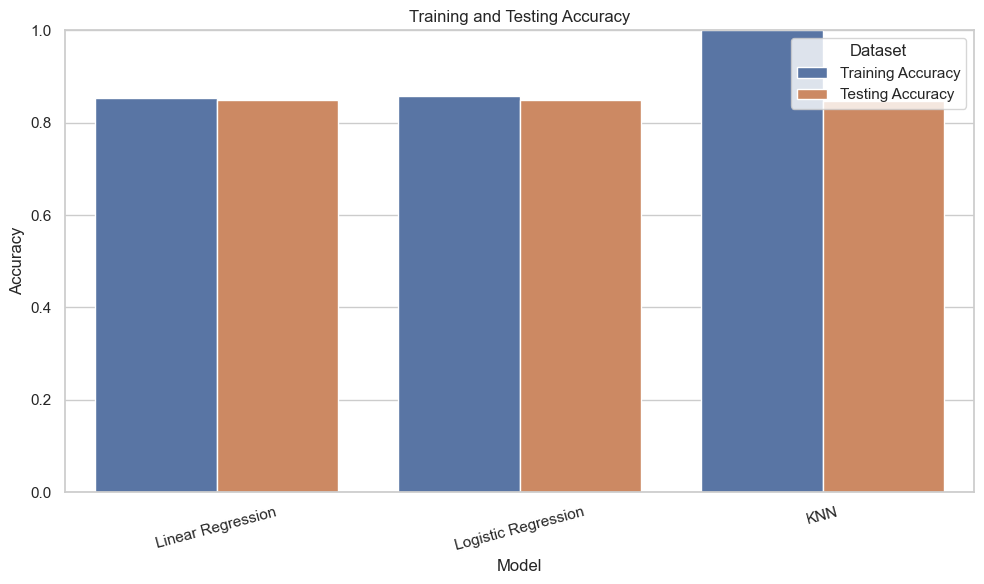

In [79]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=accuracy_long,
    x="Model",
    y="Accuracy",
    hue="Dataset"
)

plt.title("Training and Testing Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "training_testing_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

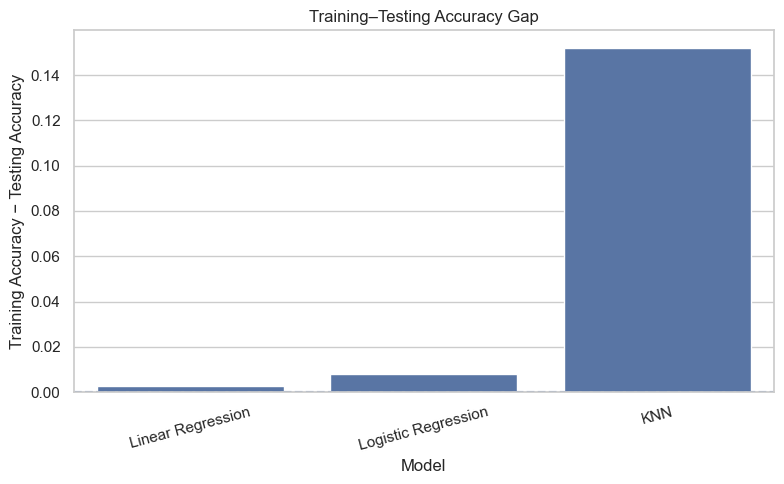

In [80]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=training_testing_accuracy,
    x="Model",
    y="Accuracy Gap"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Training–Testing Accuracy Gap")
plt.xlabel("Model")
plt.ylabel("Training Accuracy − Testing Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "accuracy_gap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
print(predictions.columns.tolist())

['Actual', 'Linear_Predicted_Value', 'Linear_Predicted_Class', 'Logistic_Probability', 'Logistic_Predicted_Class', 'KNN_Probability', 'KNN_Predicted_Class']


In [82]:
actual = predictions["Actual"]

linear_predictions = predictions[
    "Linear_Predicted_Class"
]

logistic_predictions = predictions[
    "Logistic_Predicted_Class"
]

knn_predictions = predictions[
    "KNN_Predicted_Class"
]

In [83]:
linear_confusion_matrix = confusion_matrix(
    actual,
    linear_predictions
)

logistic_confusion_matrix = confusion_matrix(
    actual,
    logistic_predictions
)

knn_confusion_matrix = confusion_matrix(
    actual,
    knn_predictions
)

In [84]:
def confusion_matrix_table(matrix):
    return pd.DataFrame(
        matrix,
        index=[
            "Actual No CHD",
            "Actual CHD"
        ],
        columns=[
            "Predicted No CHD",
            "Predicted CHD"
        ]
    )

In [85]:
print("Linear Regression")
display(
    confusion_matrix_table(
        linear_confusion_matrix
    )
)

print("Logistic Regression")
display(
    confusion_matrix_table(
        logistic_confusion_matrix
    )
)

print("KNN")
display(
    confusion_matrix_table(
        knn_confusion_matrix
    )
)

Linear Regression


,Predicted No CHD,Predicted CHD
Actual No CHD,717,2
Actual CHD,125,4


Logistic Regression


,Predicted No CHD,Predicted CHD
Actual No CHD,711,8
Actual CHD,120,9


KNN


,Predicted No CHD,Predicted CHD
Actual No CHD,716,3
Actual CHD,126,3


In [86]:
confusion_results = []

model_predictions = {
    "Linear Regression":
        linear_predictions,

    "Logistic Regression":
        logistic_predictions,

    "KNN":
        knn_predictions
}

for model_name, predicted_values in (
    model_predictions.items()
):
    tn, fp, fn, tp = confusion_matrix(
        actual,
        predicted_values
    ).ravel()

    confusion_results.append({
        "Model": model_name,
        "True Negatives": tn,
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp
    })

confusion_results_df = pd.DataFrame(
    confusion_results
)

confusion_results_df

,Model,True Negatives,False Positives,False Negatives,True Positives
0,Linear Regression,717,2,125,4
1,Logistic Regression,711,8,120,9
2,KNN,716,3,126,3


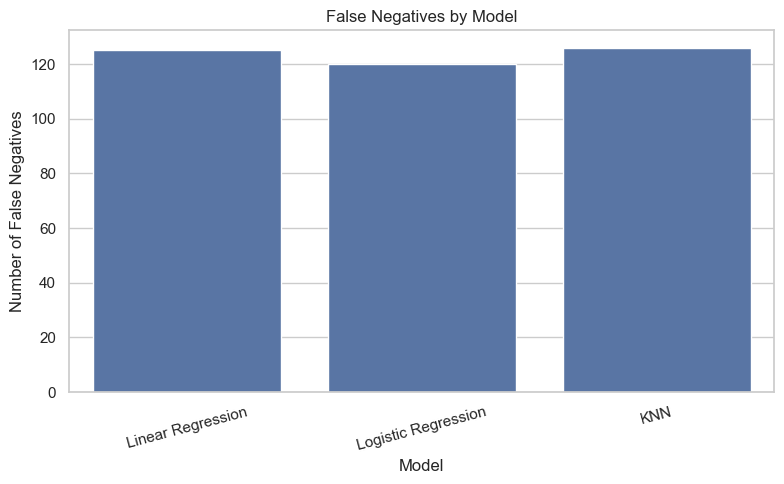

In [87]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=confusion_results_df,
    x="Model",
    y="False Negatives"
)

plt.title("False Negatives by Model")
plt.xlabel("Model")
plt.ylabel("Number of False Negatives")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "false_negatives_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

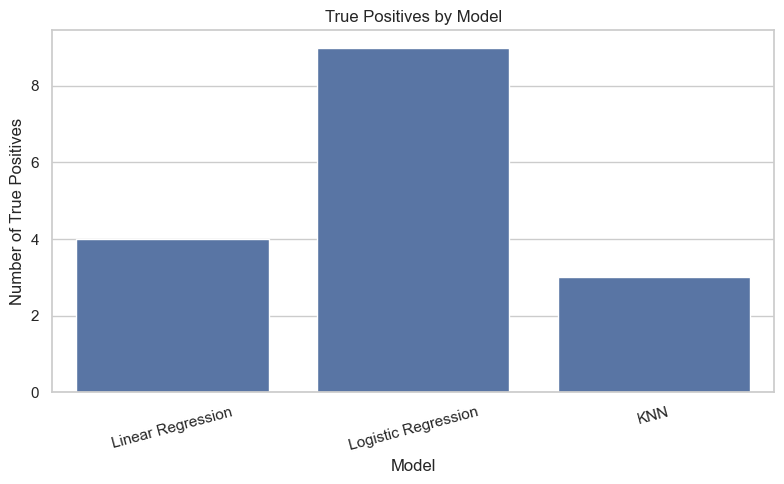

In [88]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=confusion_results_df,
    x="Model",
    y="True Positives"
)

plt.title("True Positives by Model")
plt.xlabel("Model")
plt.ylabel("Number of True Positives")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "true_positives_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
linear_scores = predictions[
    "Linear_Predicted_Value"
]

logistic_scores = predictions[
    "Logistic_Probability"
]

knn_scores = predictions[
    "KNN_Probability"
]

In [90]:
linear_fpr, linear_tpr, _ = roc_curve(
    actual,
    linear_scores
)

logistic_fpr, logistic_tpr, _ = roc_curve(
    actual,
    logistic_scores
)

knn_fpr, knn_tpr, _ = roc_curve(
    actual,
    knn_scores
)

In [91]:
linear_auc = roc_auc_score(
    actual,
    linear_scores
)

logistic_auc = roc_auc_score(
    actual,
    logistic_scores
)

knn_auc = roc_auc_score(
    actual,
    knn_scores
)

print(
    "Linear Regression ROC-AUC:",
    round(linear_auc, 4)
)

print(
    "Logistic Regression ROC-AUC:",
    round(logistic_auc, 4)
)

print(
    "KNN ROC-AUC:",
    round(knn_auc, 4)
)

Linear Regression ROC-AUC: 0.6952
Logistic Regression ROC-AUC: 0.6996
KNN ROC-AUC: 0.6511


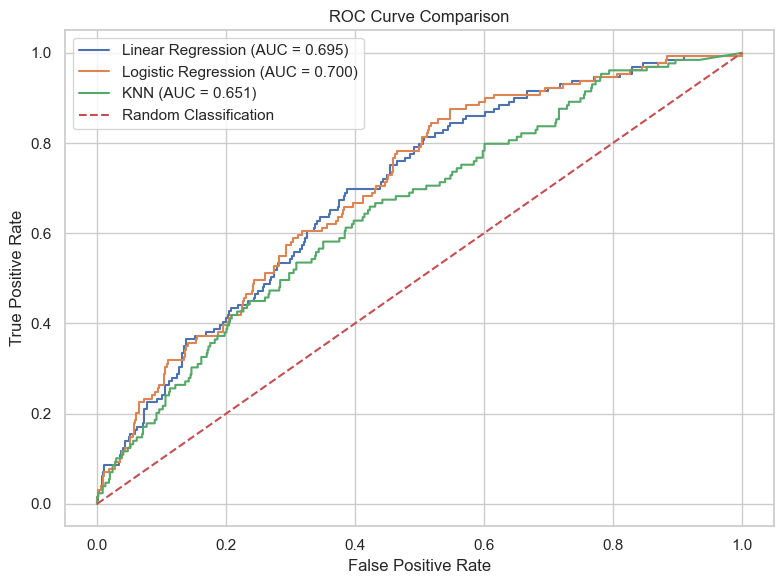

In [92]:
plt.figure(figsize=(8, 6))

plt.plot(
    linear_fpr,
    linear_tpr,
    label=(
        "Linear Regression "
        f"(AUC = {linear_auc:.3f})"
    )
)

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=(
        "Logistic Regression "
        f"(AUC = {logistic_auc:.3f})"
    )
)

plt.plot(
    knn_fpr,
    knn_tpr,
    label=(
        "KNN "
        f"(AUC = {knn_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classification"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [93]:
probability_comparison = pd.DataFrame({
    "Actual": actual,
    "Linear Regression": linear_scores,
    "Logistic Regression": logistic_scores,
    "KNN": knn_scores
})

In [94]:
probability_long = probability_comparison.melt(
    id_vars="Actual",
    var_name="Model",
    value_name="Predicted Probability"
)

probability_long.head()

,Actual,Model,Predicted Probability
0,0,Linear Regression,0.205354
1,0,Linear Regression,0.231530
2,1,Linear Regression,0.222698
3,0,Linear Regression,0.444408
4,0,Linear Regression,0.220795


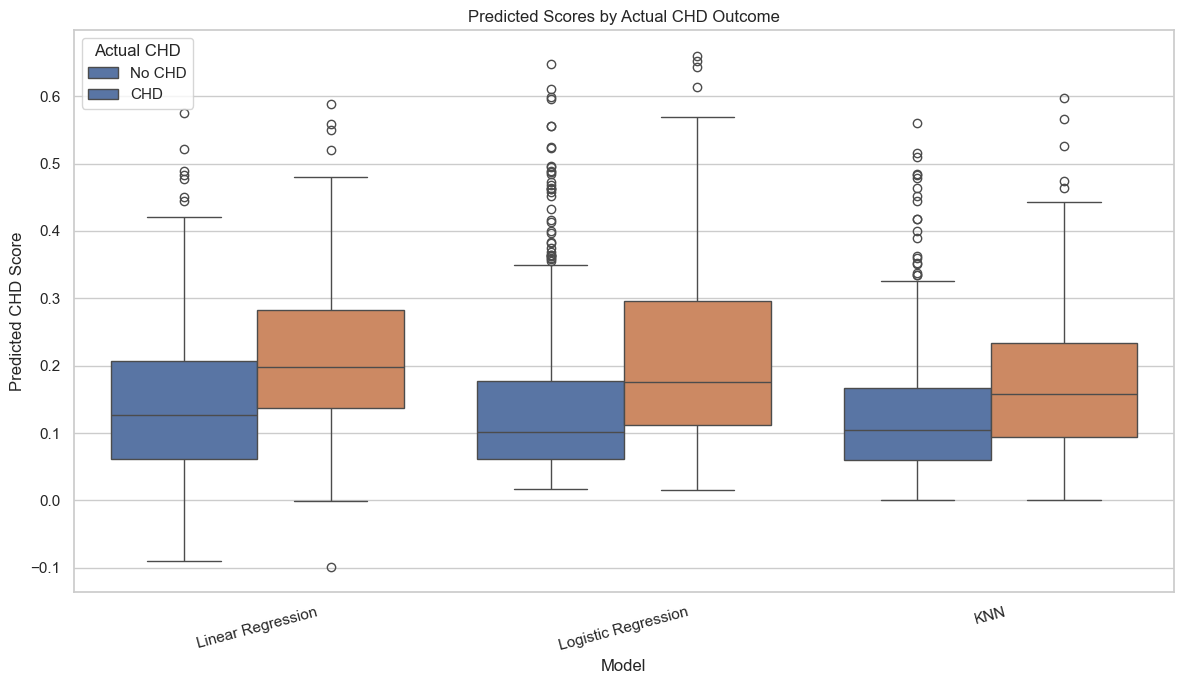

In [95]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=probability_long,
    x="Model",
    y="Predicted Probability",
    hue="Actual"
)

plt.title(
    "Predicted Scores by Actual CHD Outcome"
)
plt.xlabel("Model")
plt.ylabel("Predicted CHD Score")
plt.xticks(rotation=15)
plt.legend(
    title="Actual CHD",
    labels=["No CHD", "CHD"]
)
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "predicted_score_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [96]:
logistic_coefficients[
    "Absolute Coefficient"
] = logistic_coefficients[
    "Coefficient"
].abs()

logistic_coefficients_sorted = (
    logistic_coefficients
    .sort_values(
        by="Absolute Coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

logistic_coefficients_sorted

,Feature,Coefficient,Odds Ratio,Absolute Coefficient
0,prevalentStroke,0.834893,2.304567,0.834893
1,age,0.572034,1.771867,0.572034
2,male,0.452382,1.572052,0.452382
3,BPMeds,0.334118,1.396708,0.334118
4,sysBP,0.323828,1.382409,0.323828
5,cigsPerDay,0.315410,1.370821,0.315410
6,prevalentHyp,0.175009,1.191257,0.175009
7,glucose,0.165155,1.179575,0.165155
8,diabetes,0.126584,1.134945,0.126584
9,totChol,0.098663,1.103695,0.098663


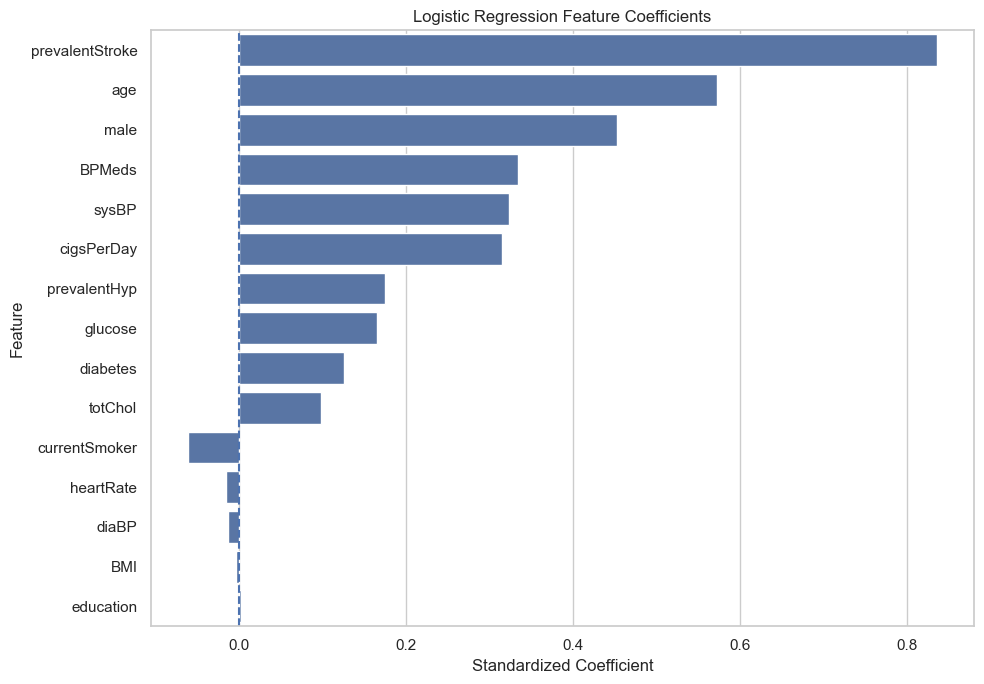

In [97]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=logistic_coefficients_sorted,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.title(
    "Logistic Regression Feature Coefficients"
)
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "logistic_feature_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [98]:
odds_ratio_data = (
    logistic_coefficients
    .sort_values(
        by="Odds Ratio",
        ascending=False
    )
)

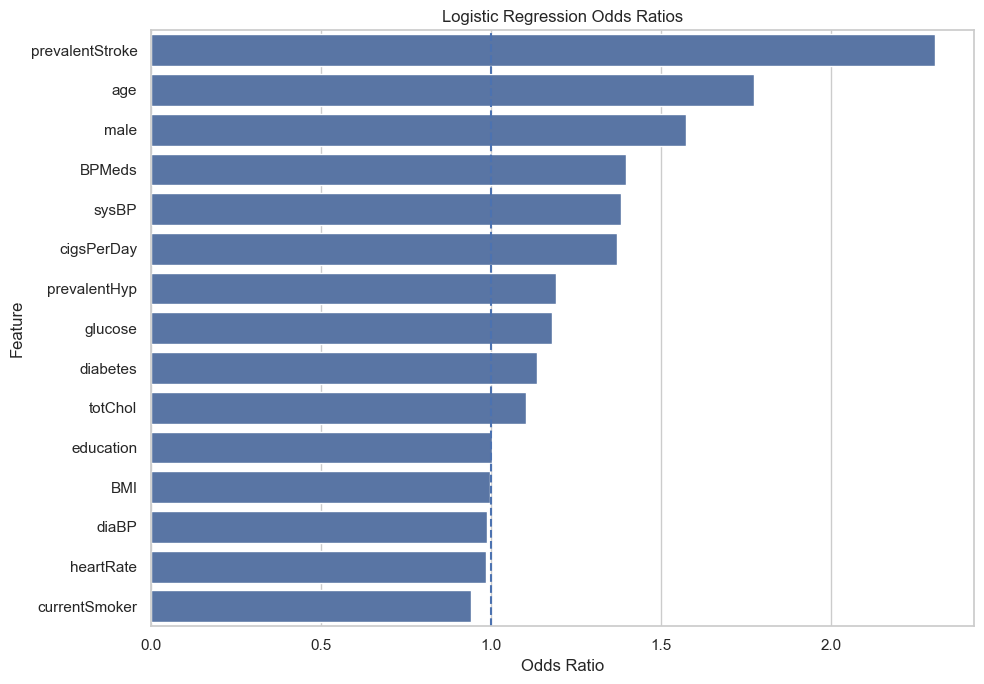

In [99]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=odds_ratio_data,
    x="Odds Ratio",
    y="Feature"
)

plt.axvline(
    x=1,
    linestyle="--"
)

plt.title(
    "Logistic Regression Odds Ratios"
)
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "logistic_odds_ratios.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [100]:
knn_grid_results.head(10)

,param_n_neighbors,param_weights,param_metric,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,31,distance,euclidean,1.000000,0.691919,0.021103,1
1,31,uniform,euclidean,0.773168,0.691314,0.020868,2
2,25,distance,manhattan,1.000000,0.688361,0.019706,3
3,29,distance,euclidean,1.000000,0.687416,0.021296,4
4,27,distance,manhattan,1.000000,0.686875,0.019294,5
5,23,distance,manhattan,1.000000,0.686551,0.017158,6
6,31,distance,manhattan,1.000000,0.686492,0.019988,7
7,29,distance,manhattan,1.000000,0.686349,0.019831,8
8,29,uniform,euclidean,0.774865,0.686079,0.020905,9
9,25,uniform,manhattan,0.779068,0.685374,0.020774,10


In [101]:
knn_grid_results[
    "param_n_neighbors"
] = pd.to_numeric(
    knn_grid_results[
        "param_n_neighbors"
    ]
)

In [102]:
best_knn_row = (
    knn_grid_results
    .sort_values(
        by="rank_test_score"
    )
    .iloc[0]
)

best_knn_summary = pd.DataFrame({
    "Setting": [
        "Number of Neighbors",
        "Weights",
        "Distance Metric",
        "Cross-Validation ROC-AUC"
    ],
    "Value": [
        best_knn_row[
            "param_n_neighbors"
        ],
        best_knn_row[
            "param_weights"
        ],
        best_knn_row[
            "param_metric"
        ],
        round(
            best_knn_row[
                "mean_test_score"
            ],
            4
        )
    ]
})

best_knn_summary

,Setting,Value
0,Number of Neighbors,31
1,Weights,distance
2,Distance Metric,euclidean
3,Cross-Validation ROC-AUC,0.6919


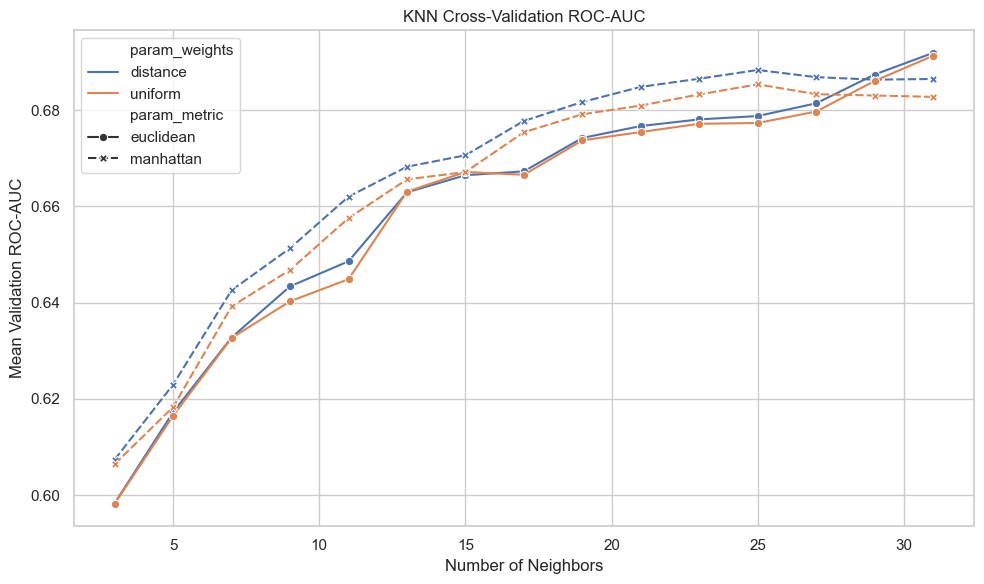

In [103]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=knn_grid_results,
    x="param_n_neighbors",
    y="mean_test_score",
    hue="param_weights",
    style="param_metric",
    markers=True
)

plt.title(
    "KNN Cross-Validation ROC-AUC"
)
plt.xlabel("Number of Neighbors")
plt.ylabel("Mean Validation ROC-AUC")
plt.tight_layout()

plt.savefig(
    comparison_figures_folder /
    "knn_tuning_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [104]:
ranked_metrics = (
    classification_metrics.copy()
)

for metric in metric_columns:
    ranked_metrics[
        f"{metric} Rank"
    ] = ranked_metrics[
        metric
    ].rank(
        ascending=False,
        method="min"
    )

ranked_metrics

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Accuracy Rank,Precision Rank,Recall Rank,F1 Score Rank,ROC AUC Rank
0,Linear Regression,0.8502,0.6667,0.0310,0.0593,0.6952,1.0,1.0,2.0,2.0,2.0
1,Logistic Regression,0.8491,0.5294,0.0698,0.1233,0.6996,2.0,2.0,1.0,1.0,1.0
2,KNN,0.8479,0.5000,0.0233,0.0444,0.6511,3.0,3.0,3.0,3.0,3.0


In [105]:
rank_columns = [
    f"{metric} Rank"
    for metric in metric_columns
]

ranked_metrics[
    "Average Rank"
] = ranked_metrics[
    rank_columns
].mean(axis=1)

ranked_metrics = (
    ranked_metrics
    .sort_values(
        by="Average Rank"
    )
    .reset_index(drop=True)
)

ranked_metrics[
    [
        "Model",
        "Average Rank"
    ]
]

,Model,Average Rank
0,Logistic Regression,1.4
1,Linear Regression,1.6
2,KNN,3.0


In [106]:
best_auc_row = classification_metrics.loc[
    classification_metrics[
        "ROC AUC"
    ].idxmax()
]

print(
    "Best model by ROC-AUC:",
    best_auc_row["Model"]
)

print(
    "ROC-AUC:",
    best_auc_row["ROC AUC"]
)

Best model by ROC-AUC: Logistic Regression
ROC-AUC: 0.6996


In [107]:
best_recall_row = classification_metrics.loc[
    classification_metrics[
        "Recall"
    ].idxmax()
]

print(
    "Best model by recall:",
    best_recall_row["Model"]
)

print(
    "Recall:",
    best_recall_row["Recall"]
)

Best model by recall: Logistic Regression
Recall: 0.0698


In [108]:
lowest_fn_row = confusion_results_df.loc[
    confusion_results_df[
        "False Negatives"
    ].idxmin()
]

print(
    "Model with fewest false negatives:",
    lowest_fn_row["Model"]
)

print(
    "False negatives:",
    lowest_fn_row["False Negatives"]
)

Model with fewest false negatives: Logistic Regression
False negatives: 120


In [109]:
final_model_summary = (
    classification_metrics
    .merge(
        training_testing_accuracy[
            [
                "Model",
                "Training Accuracy",
                "Testing Accuracy",
                "Accuracy Gap"
            ]
        ],
        on="Model",
        how="left"
    )
    .merge(
        confusion_results_df,
        on="Model",
        how="left"
    )
)

final_model_summary

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Accuracy,Testing Accuracy,Accuracy Gap,True Negatives,False Positives,False Negatives,True Positives
0,Linear Regression,0.8502,0.6667,0.0310,0.0593,0.6952,0.8531,0.8502,0.0029,717,2,125,4
1,Logistic Regression,0.8491,0.5294,0.0698,0.1233,0.6996,0.8572,0.8491,0.0081,711,8,120,9
2,KNN,0.8479,0.5000,0.0233,0.0444,0.6511,1.0000,0.8479,0.1521,716,3,126,3


In [110]:
final_model_summary = (
    final_model_summary
    .merge(
        ranked_metrics[
            [
                "Model",
                "Average Rank"
            ]
        ],
        on="Model",
        how="left"
    )
)

final_model_summary = (
    final_model_summary
    .sort_values(
        by="Average Rank"
    )
    .reset_index(drop=True)
)

final_model_summary

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Accuracy,Testing Accuracy,Accuracy Gap,True Negatives,False Positives,False Negatives,True Positives,Average Rank
0,Logistic Regression,0.8491,0.5294,0.0698,0.1233,0.6996,0.8572,0.8491,0.0081,711,8,120,9,1.4
1,Linear Regression,0.8502,0.6667,0.0310,0.0593,0.6952,0.8531,0.8502,0.0029,717,2,125,4,1.6
2,KNN,0.8479,0.5000,0.0233,0.0444,0.6511,1.0000,0.8479,0.1521,716,3,126,3,3.0


In [111]:
best_models_df.to_csv(
    results_folder /
    "best_model_by_metric.csv",
    index=False
)

confusion_results_df.to_csv(
    results_folder /
    "confusion_matrix_results.csv",
    index=False
)

ranked_metrics.to_csv(
    results_folder /
    "ranked_model_metrics.csv",
    index=False
)

final_model_summary.to_csv(
    results_folder /
    "final_model_comparison.csv",
    index=False
)

best_knn_summary.to_csv(
    results_folder /
    "best_knn_summary.csv",
    index=False
)

print("Comparison tables saved successfully.")

Comparison tables saved successfully.


In [112]:
print("Saved comparison figures:\n")

for file in sorted(
    comparison_figures_folder.glob("*.png")
):
    print("-", file.name)

Saved comparison figures:

- accuracy_comparison.png
- accuracy_gap.png
- all_metrics_comparison.png
- f1_score_comparison.png
- false_negatives_comparison.png
- knn_tuning_comparison.png
- logistic_feature_coefficients.png
- logistic_odds_ratios.png
- precision_comparison.png
- predicted_score_distributions.png
- recall_comparison.png
- roc_auc_comparison.png
- roc_curve_comparison.png
- training_testing_accuracy.png
- true_positives_comparison.png


In [113]:
display_columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "False Negatives",
    "True Positives",
    "Accuracy Gap",
    "Average Rank"
]

final_model_summary[
    display_columns
].round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,False Negatives,True Positives,Accuracy Gap,Average Rank
0,Logistic Regression,0.8491,0.5294,0.0698,0.1233,0.6996,120,9,0.0081,1.4
1,Linear Regression,0.8502,0.6667,0.0310,0.0593,0.6952,125,4,0.0029,1.6
2,KNN,0.8479,0.5000,0.0233,0.0444,0.6511,126,3,0.1521,3.0


In [114]:
best_overall_model = final_model_summary.iloc[0]

print(
    f"The highest-ranked overall model was "
    f"{best_overall_model['Model']}."
)

print(
    f"It achieved an accuracy of "
    f"{best_overall_model['Accuracy']:.3f}, "
    f"a recall of "
    f"{best_overall_model['Recall']:.3f}, "
    f"an F1 score of "
    f"{best_overall_model['F1 Score']:.3f}, "
    f"and a ROC-AUC of "
    f"{best_overall_model['ROC AUC']:.3f}."
)

print(
    f"It produced "
    f"{int(best_overall_model['False Negatives'])} "
    f"false-negative predictions."
)

The highest-ranked overall model was Logistic Regression.
It achieved an accuracy of 0.849, a recall of 0.070, an F1 score of 0.123, and a ROC-AUC of 0.700.
It produced 120 false-negative predictions.
